In [1]:
import pickle
from cmdstanpy import CmdStanModel
import arviz as az

In [ ]:
"""
thin = 10 to prevent autocorrelation issues
iter_sampling = 10000 to get enough samples after thinning
"""

model = CmdStanModel(stan_file='trape8.stan')
fit = model.sample(data='trape_populations.json', show_console=False, show_progress=True, thin=10, iter_sampling=10000, chains=4, parallel_chains=4)

draws = fit.draws_pd()
draws.to_csv('trape8_draws.csv')
with open('trape8_fit.pickle', 'wb') as f:
    pickle.dump(fit, f)

In [2]:
with open('trape8_fit.pickle', 'rb') as f:
    fit = pickle.load(f)
# print(fit.diagnose())

In [3]:
z = az.from_cmdstanpy(fit)
z

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats

In [6]:
vars = ['lambda', 'rho_elp', 'tau_elp', 'rho_clinical', 'delta_clinical', 'gamma_clinical']


Rhat values good

In [7]:

print(az.rhat(fit, var_names=vars))

<xarray.Dataset> Size: 72B
Dimensions:         (lambda_dim_0: 2)
Coordinates:
  * lambda_dim_0    (lambda_dim_0) int64 16B 0 1
Data variables:
    lambda          (lambda_dim_0) float64 16B 1.0 1.0
    rho_elp         float64 8B 1.001
    tau_elp         float64 8B 1.001
    rho_clinical    float64 8B 1.0
    delta_clinical  float64 8B 1.001
    gamma_clinical  float64 8B 1.0


Effective samples sizes good

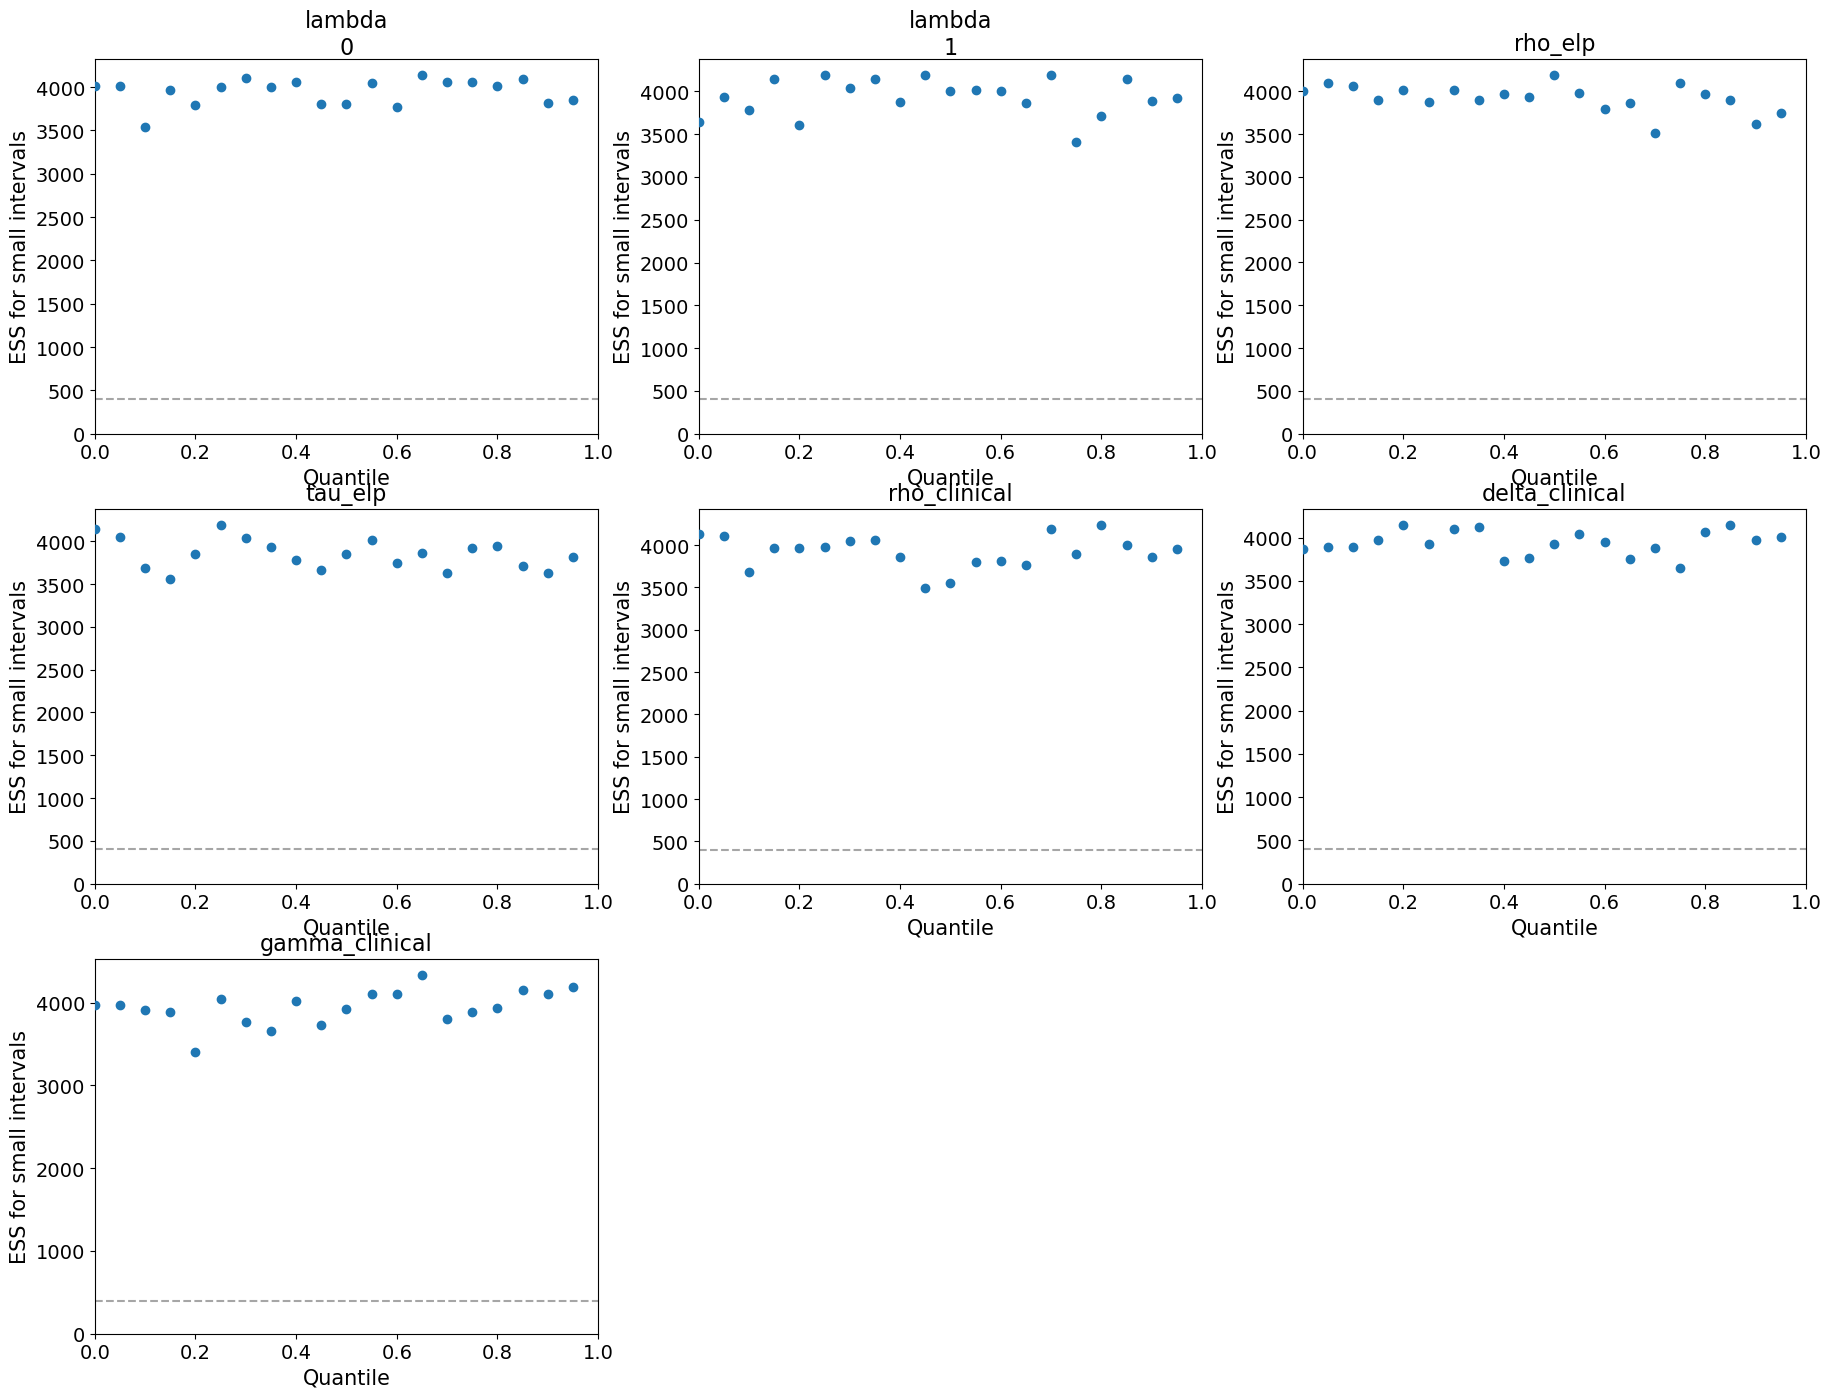

In [9]:
az.plot_ess(fit, var_names=vars);

No autocorrelation with thin = 10

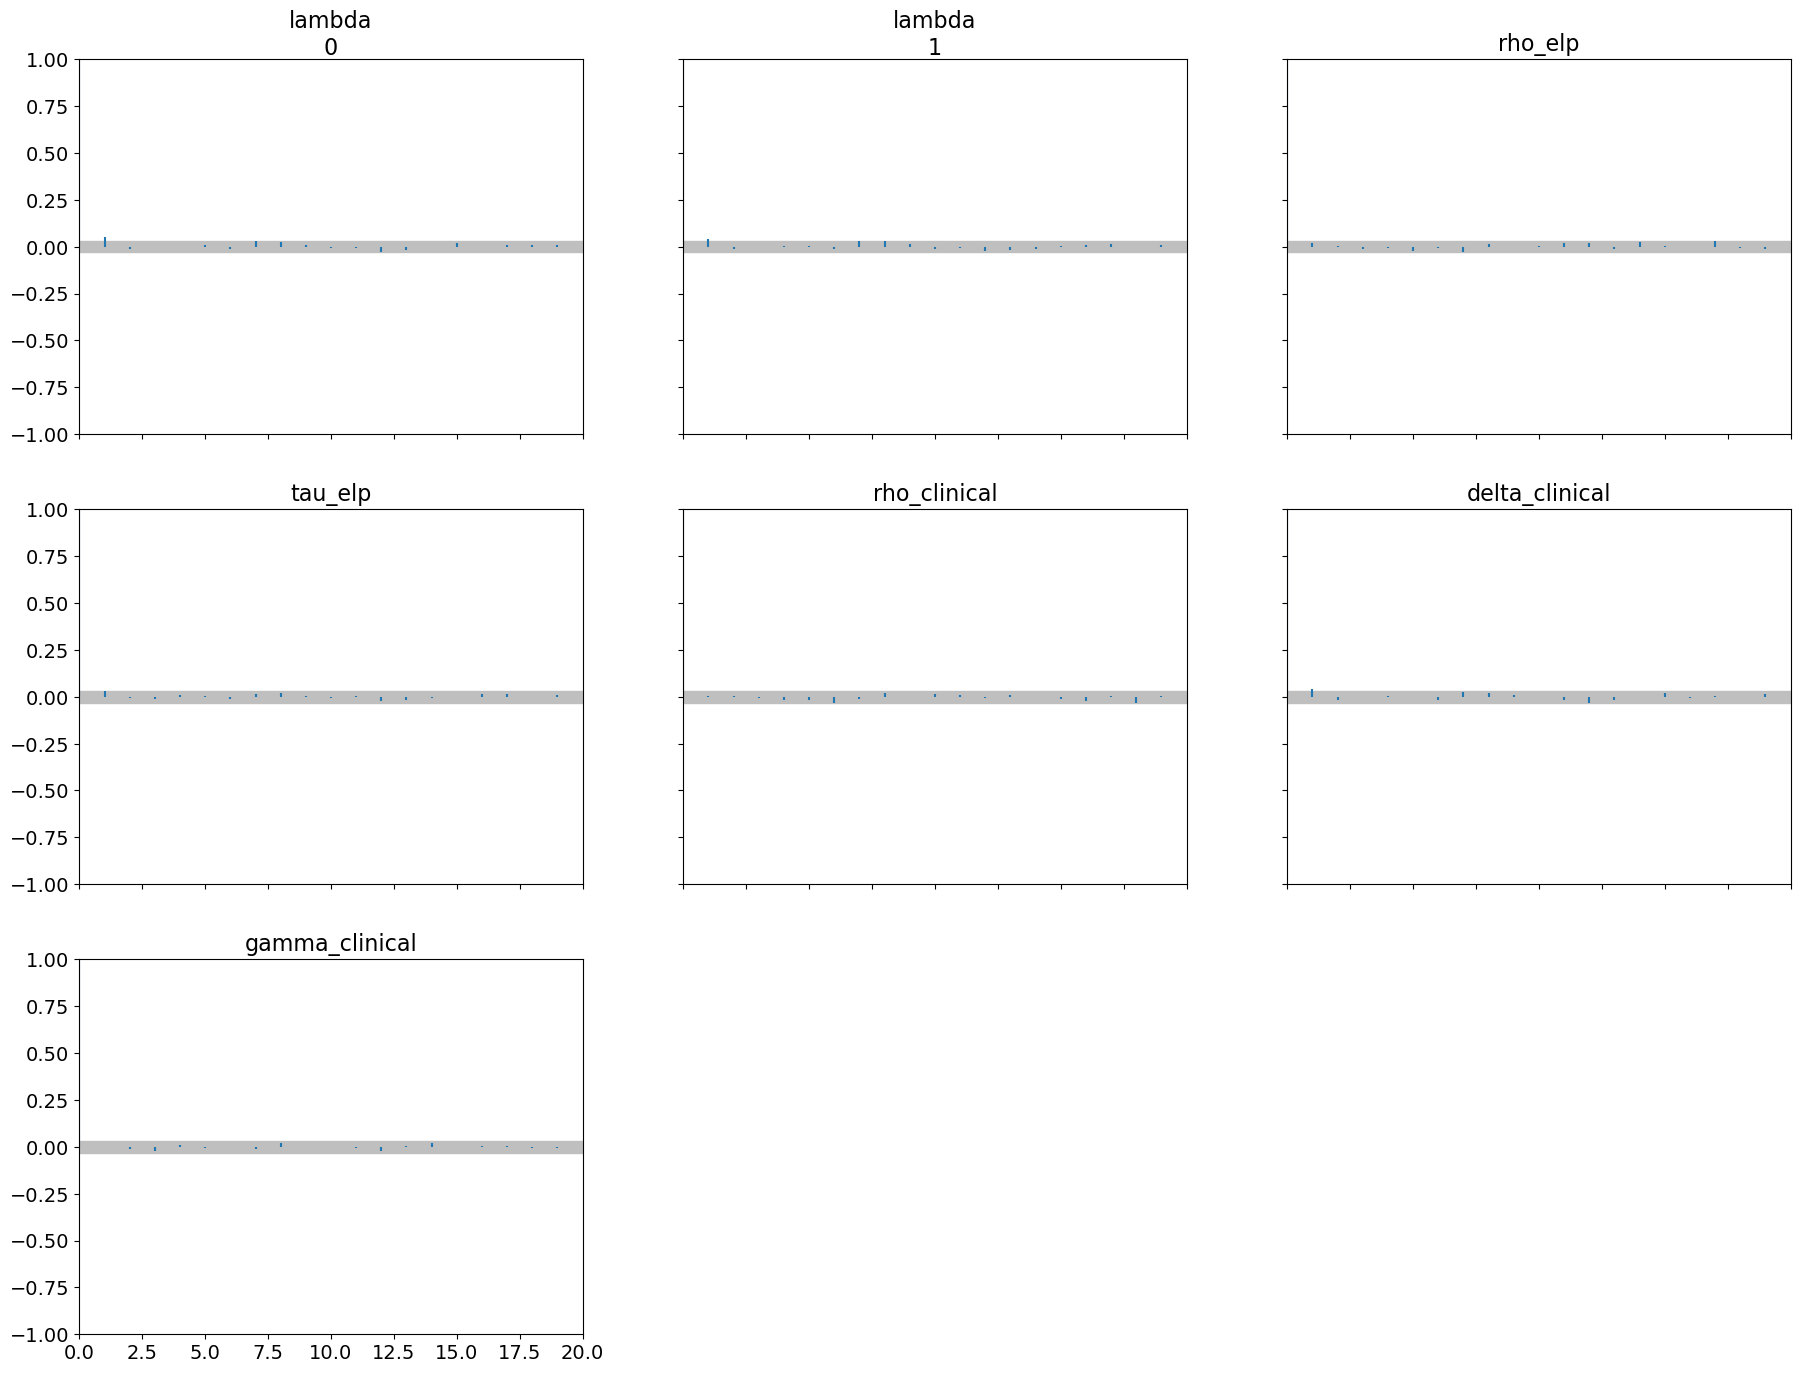

In [10]:
az.plot_autocorr(fit, var_names=vars, combined=True, max_lag=20,);

Chains look good

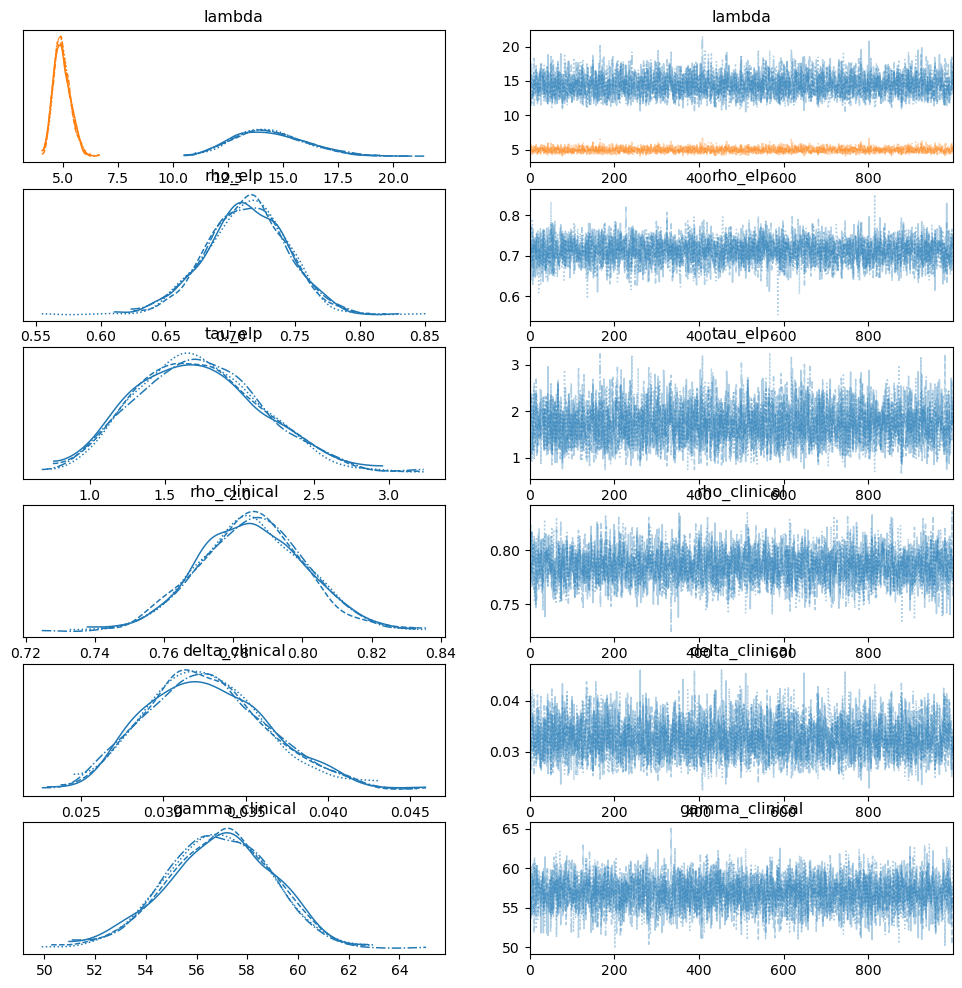

In [11]:
az.plot_trace(fit, var_names=vars);

Pair plot reveals identifiability issue between many parameters

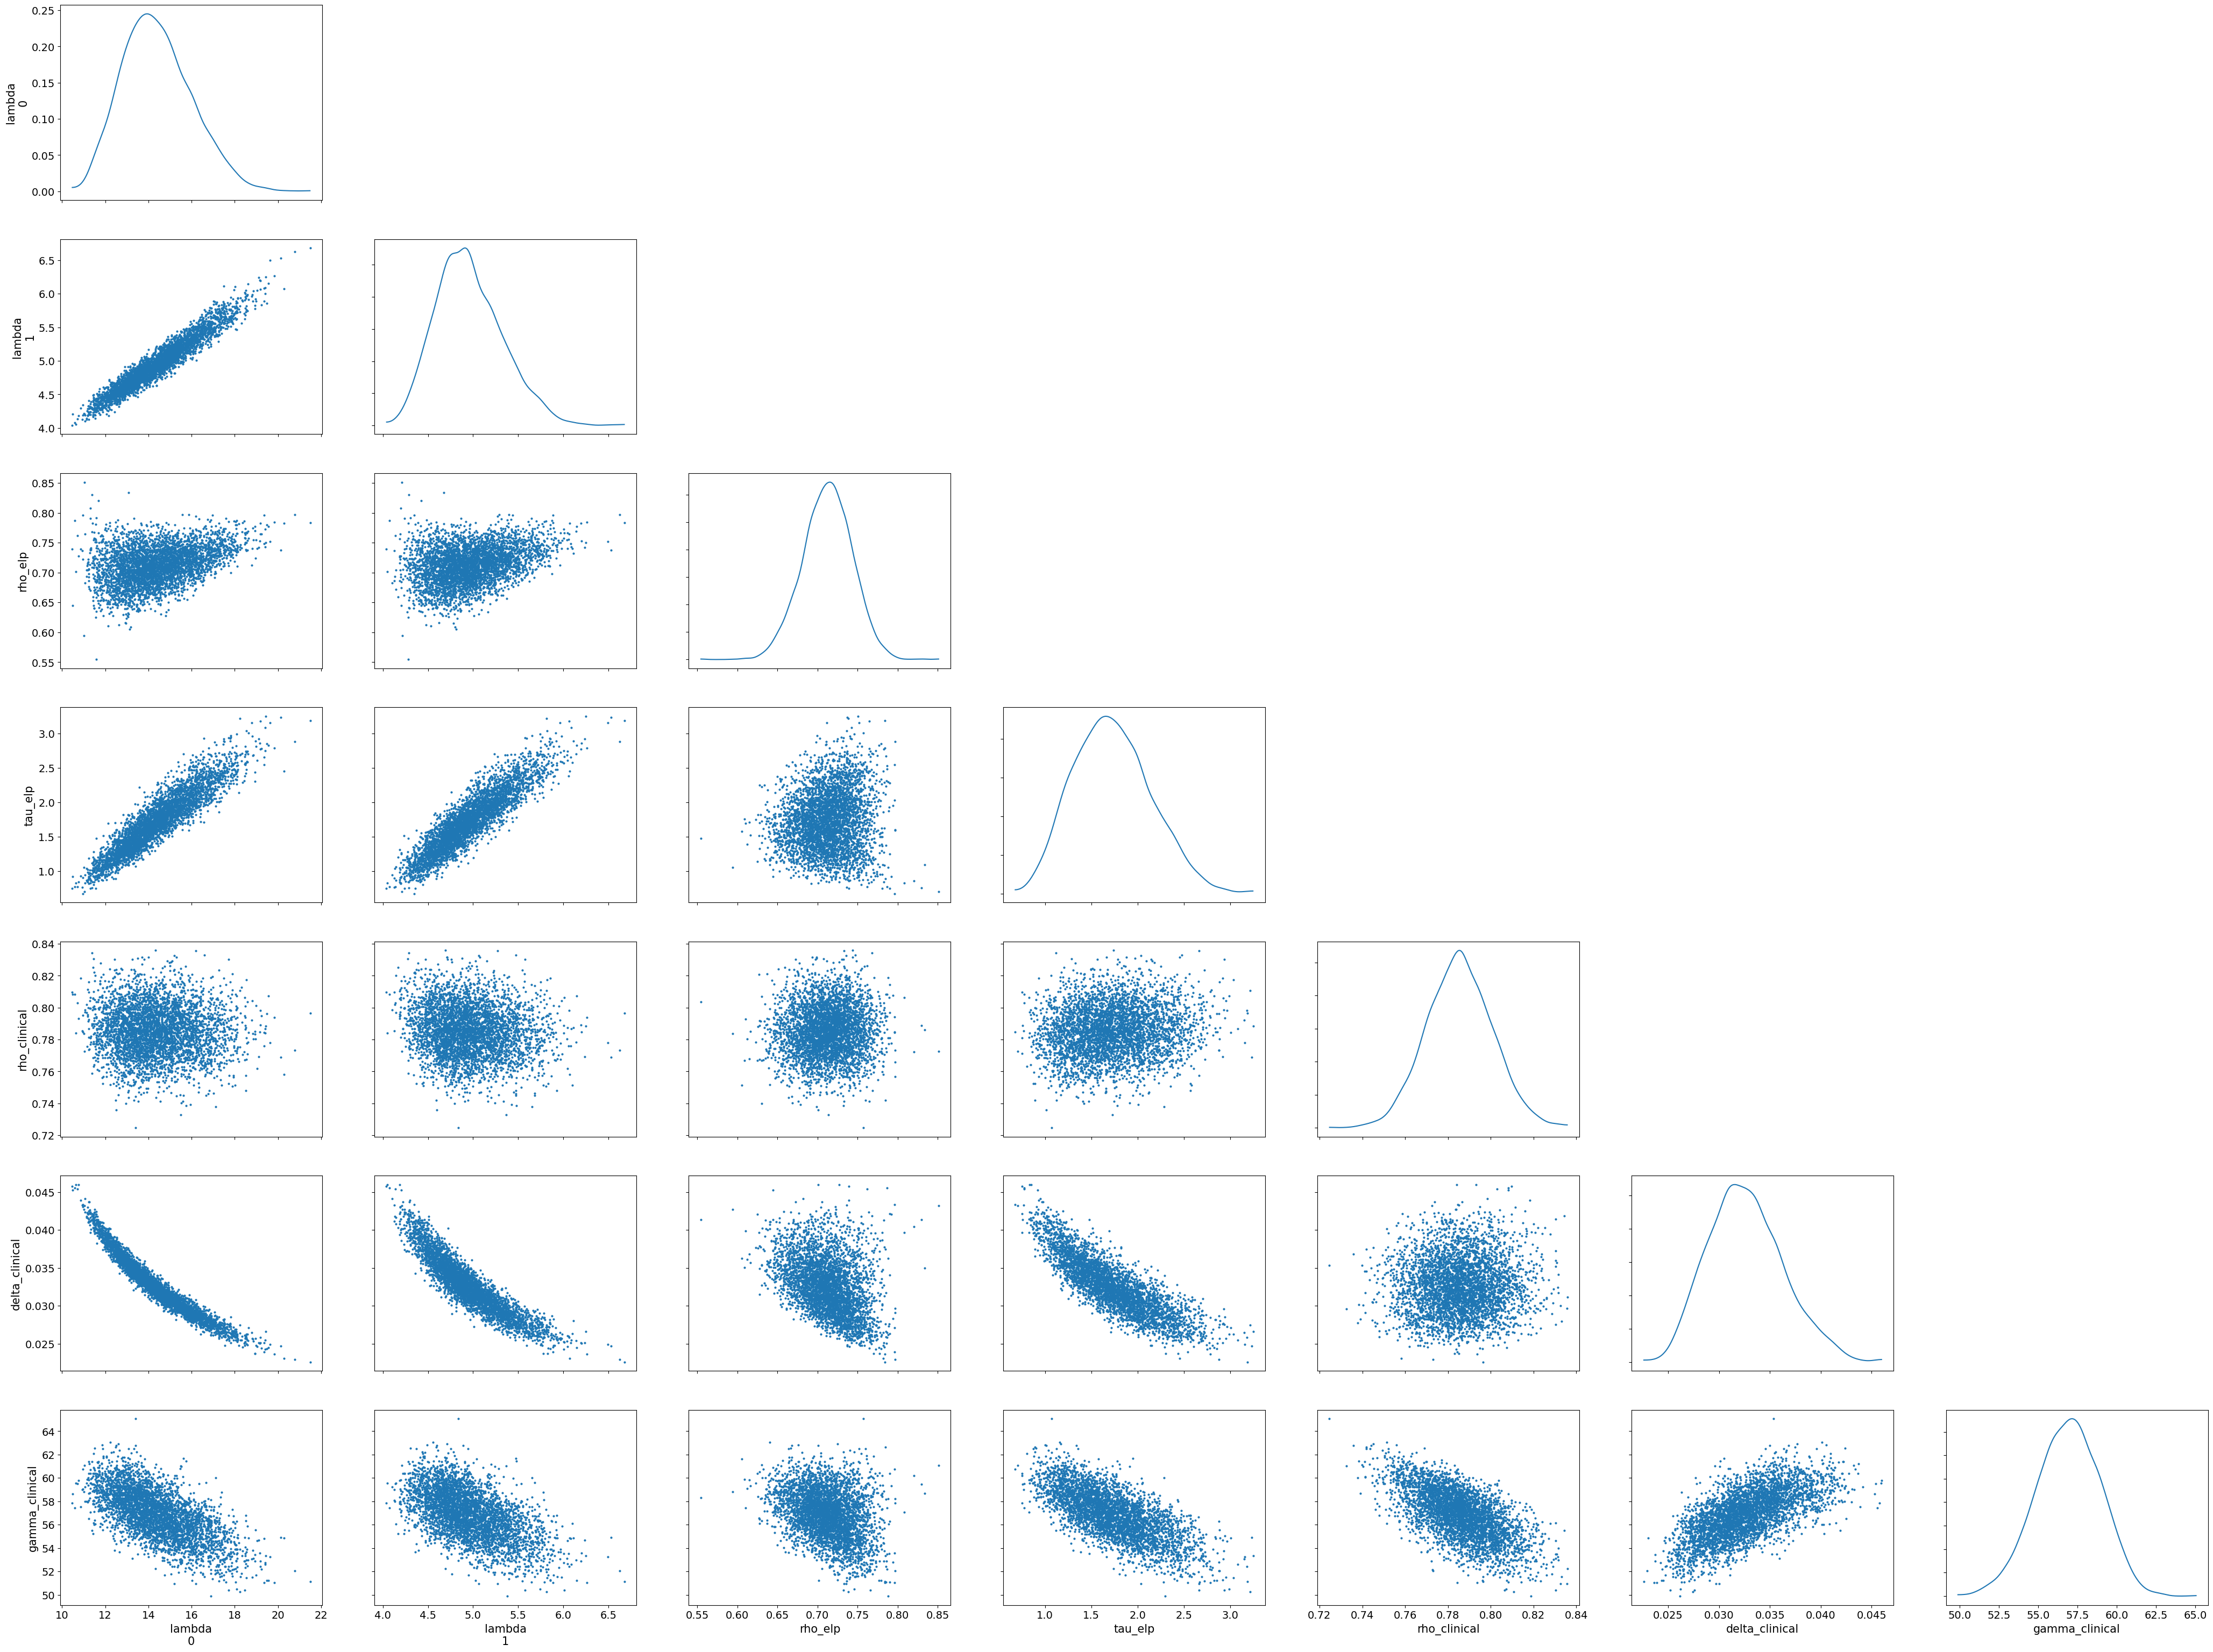

In [13]:
az.plot_pair(fit, var_names=vars, marginals=True);